**Gaussian**


TRAIN : TEST = 6 : 4

Confusion Matrix:
[[58 85]
 [ 0 85]]

Performance Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.41      0.58       143
           1       0.50      1.00      0.67        85

    accuracy                           0.63       228
   macro avg       0.75      0.70      0.62       228
weighted avg       0.81      0.63      0.61       228



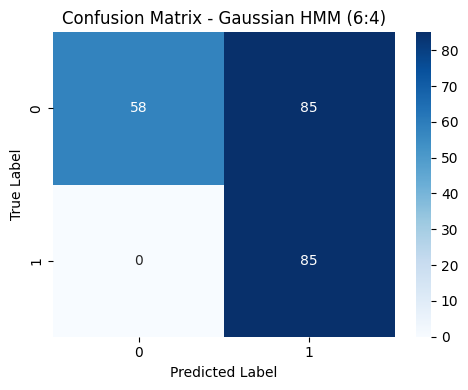


TRAIN : TEST = 7 : 3

Confusion Matrix:
[[107   0]
 [ 49  15]]

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.69      1.00      0.81       107
           1       1.00      0.23      0.38        64

    accuracy                           0.71       171
   macro avg       0.84      0.62      0.60       171
weighted avg       0.80      0.71      0.65       171



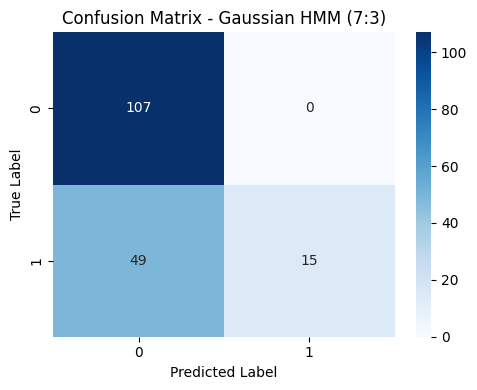


TRAIN : TEST = 8 : 2

Confusion Matrix:
[[50 22]
 [ 2 40]]

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.96      0.69      0.81        72
           1       0.65      0.95      0.77        42

    accuracy                           0.79       114
   macro avg       0.80      0.82      0.79       114
weighted avg       0.84      0.79      0.79       114



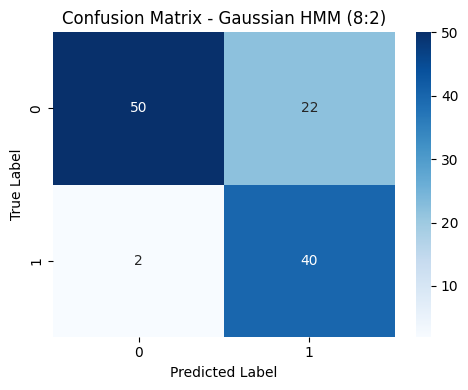

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Dataset Preparation
# ==========================================

dataset = pd.read_csv("/content/wdbc.data", header=None)

X = dataset.iloc[:, 2:]     # skip ID and diagnosis columns
y = dataset.iloc[:, 1]      # diagnosis column

# Convert M/B into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# ==========================================
# 2. Imports
# ==========================================

from sklearn.model_selection import train_test_split
from hmmlearn import hmm
from sklearn.metrics import classification_report, confusion_matrix


# ==========================================
# 3. Function for Supervised HMM
# ==========================================

def run_hmm(X, y, test_size):

    # --------------------------------------
    # Train-test split
    # --------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Convert DataFrames to NumPy arrays
    X_train = X_train.to_numpy()
    X_test = X_test.to_numpy()

    # --------------------------------------
    # Separate training data by class
    # --------------------------------------

    X_train_0 = X_train[y_train == 0]
    X_train_1 = X_train[y_train == 1]

    # --------------------------------------
    # Create HMM for each class
    # --------------------------------------

    model_0 = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=2000,
        random_state=42
    )

    model_1 = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    # --------------------------------------
    # Train separately
    # --------------------------------------

    model_0.fit(X_train_0)
    model_1.fit(X_train_1)

    # --------------------------------------
    # Prediction
    # --------------------------------------

    y_pred = []

    for sample in X_test:

        # One sample = 30 features
        sample = sample.reshape(1, -1)

        # Likelihood under class 0 HMM
        score_0 = model_0.score(sample)

        # Likelihood under class 1 HMM
        score_1 = model_1.score(sample)

        # Higher likelihood = predicted class
        if score_0 > score_1:
            y_pred.append(0)
        else:
            y_pred.append(1)

    y_pred = np.array(y_pred)

    # --------------------------------------
    # Results
    # --------------------------------------

    print("\n==============================================")
    print(f"TRAIN : TEST = {int((1-test_size)*10)} : {int(test_size*10)}")
    print("==============================================")

    print("\nConfusion Matrix:")

    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nPerformance Evaluation:")
    print(classification_report(y_test, y_pred))

    # --------------------------------------
    # Confusion Matrix Heatmap
    # --------------------------------------

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["0", "1"],
        yticklabels=["0", "1"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(
        f"Confusion Matrix - Gaussian HMM ({int((1-test_size)*10)}:{int(test_size*10)})"
    )

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. Run for 6:4
# ==========================================

run_hmm(X, y, 0.40)


# ==========================================
# 5. Run for 7:3
# ==========================================

run_hmm(X, y, 0.30)


# ==========================================
# 6. Run for 8:2
# ==========================================

run_hmm(X, y, 0.20)

Classes: ['B' 'M']
Minimum value: 0
Maximum value: 9
Data type: int64


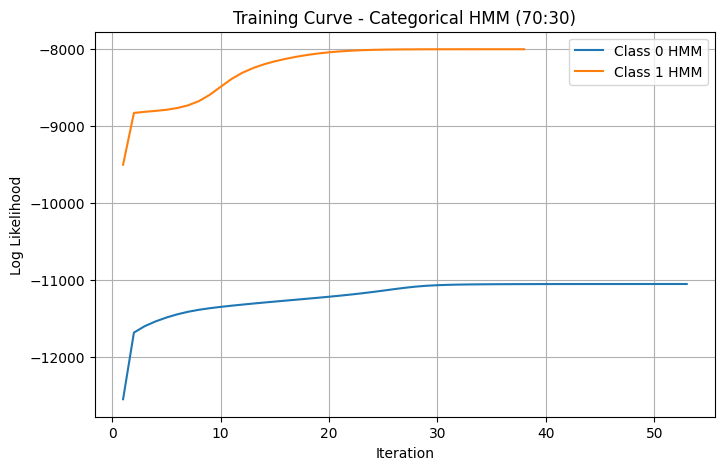

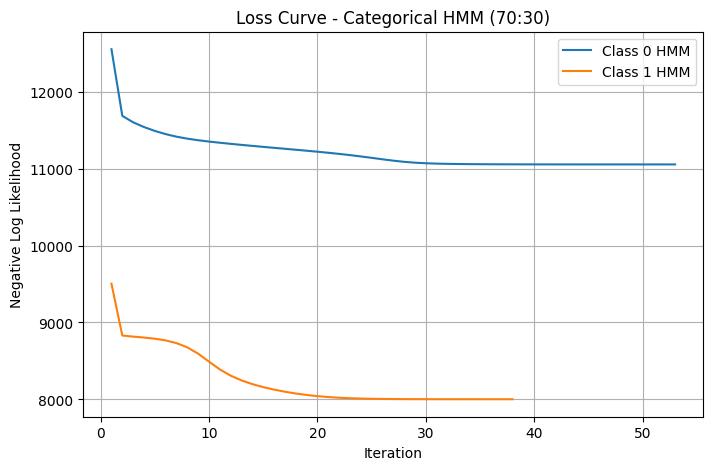


SUPERVISED CATEGORICAL HMM
BREAST CANCER DATASET
TRAIN : TEST = 70 : 30

Confusion Matrix:
[[99  8]
 [11 53]]

Accuracy:
0.8888888888888888

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       107
           1       0.87      0.83      0.85        64

    accuracy                           0.89       171
   macro avg       0.88      0.88      0.88       171
weighted avg       0.89      0.89      0.89       171



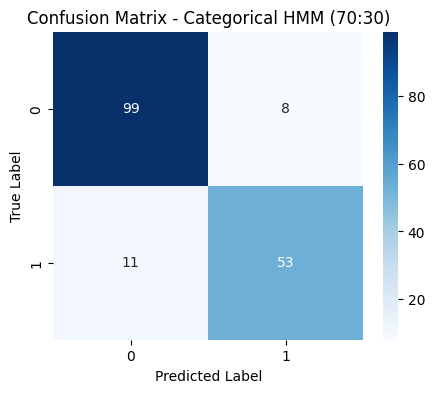

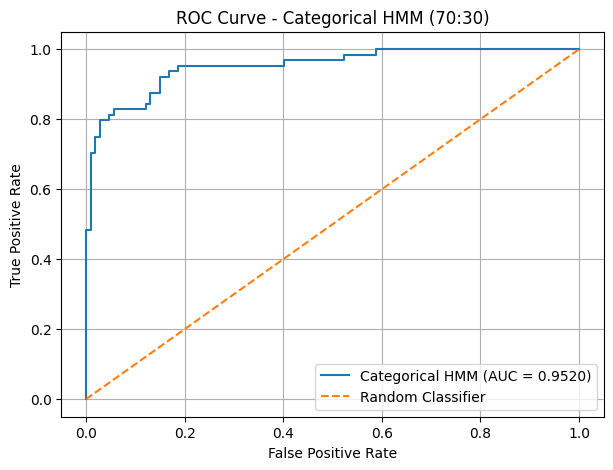


AUC: 0.9519567757009346


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Dataset Preparation
# ==========================================

dataset = pd.read_csv("/content/wdbc.data", header=None)

# WDBC:
# column 0 = ID
# column 1 = Diagnosis
# columns 2-31 = 30 features

X = dataset.iloc[:, 2:]
y = dataset.iloc[:, 1]

# Convert B/M into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

# ==========================================
# 2. Scale the data
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

# Convert values into integers from 0 to 9
X = (X * 9).astype(int)

# Make sure values are non-negative
X[X < 0] = 0

print("Minimum value:", X.min())
print("Maximum value:", X.max())
print("Data type:", X.dtype)


# ==========================================
# 3. Train-Test Split (70:30)
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ==========================================
# 4. Separate data by class
# ==========================================

X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]


# ==========================================
# 5. Convert each row into a sequence
# ==========================================

X_train_0_seq = X_train_0.reshape(-1, 1)
X_train_1_seq = X_train_1.reshape(-1, 1)

# WDBC has 30 features
lengths_0 = [30] * len(X_train_0)
lengths_1 = [30] * len(X_train_1)


# ==========================================
# 6. Create HMM models
# ==========================================

from hmmlearn import hmm

model_0 = hmm.GaussianHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)

model_1 = hmm.GaussianHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)


# ==========================================
# 7. Train the HMMs
# ==========================================

model_0.fit(
    X_train_0_seq,
    lengths=lengths_0
)

model_1.fit(
    X_train_1_seq,
    lengths=lengths_1
)


# ==========================================
# 8. Training Curves
# ==========================================

history_0 = list(model_0.monitor_.history)
history_1 = list(model_1.monitor_.history)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history_0) + 1),
    history_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(history_1) + 1),
    history_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("Training Curve - Gaussian HMM (70:30)")
plt.legend()
plt.grid()

plt.show()


# ==========================================
# 9. Loss Curves
# ==========================================

loss_0 = [-x for x in history_0]
loss_1 = [-x for x in history_1]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_0) + 1),
    loss_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(loss_1) + 1),
    loss_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Negative Log Likelihood")
plt.title("Loss Curve - Gaussian HMM (70:30)")
plt.legend()
plt.grid()

plt.show()


# ==========================================
# 10. Prediction
# ==========================================

y_pred = []
decision_scores = []

for sample in X_test:

    # One sample = 30 observations
    sample = sample.reshape(-1, 1)

    # Likelihood under class 0 HMM
    score_0 = model_0.score(sample)

    # Likelihood under class 1 HMM
    score_1 = model_1.score(sample)

    # Continuous score for ROC
    decision_score = score_1 - score_0

    decision_scores.append(decision_score)

    # Higher likelihood = predicted class
    if score_0 > score_1:
        y_pred.append(0)
    else:
        y_pred.append(1)

y_pred = np.array(y_pred)
decision_scores = np.array(decision_scores)


# ==========================================
# 11. Evaluation
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

cm = confusion_matrix(y_test, y_pred)

print("\n==============================================")
print("SUPERVISED CATEGORICAL HMM")
print("BREAST CANCER DATASET")
print("TRAIN : TEST = 70 : 30")
print("==============================================")

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPerformance Evaluation:")
print(classification_report(y_test, y_pred))


# ==========================================
# 12. Confusion Matrix Heatmap
# ==========================================

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gaussian HMM (70:30)")

plt.show()


# ==========================================
# 13. ROC Curve and AUC
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_scores
)

auc = roc_auc_score(
    y_test,
    decision_scores
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Gaussian HMM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian HMM (70:30)")
plt.legend()
plt.grid()

plt.show()

print("\nAUC:", auc)

**Multinomial without parameter**

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Classes: ['B' 'M']
Minimum: 0
Maximum: 9


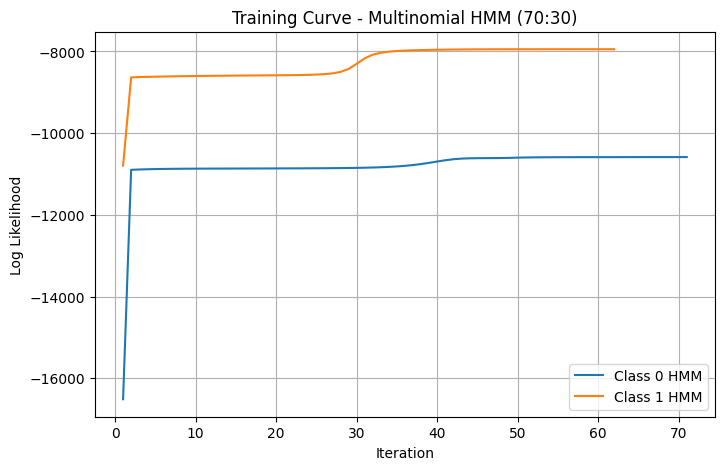

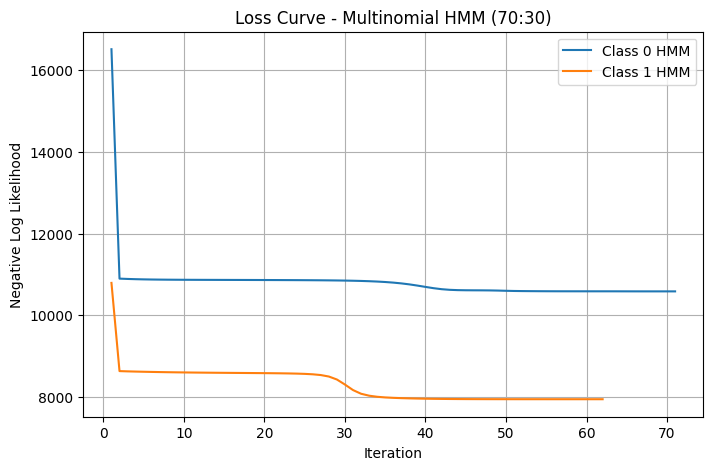


SUPERVISED MULTINOMIAL HMM
BREAST CANCER DATASET
TRAIN : TEST = 70 : 30

Confusion Matrix:
[[102   5]
 [  8  56]]

Accuracy:
0.9239766081871345

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       107
           1       0.92      0.88      0.90        64

    accuracy                           0.92       171
   macro avg       0.92      0.91      0.92       171
weighted avg       0.92      0.92      0.92       171



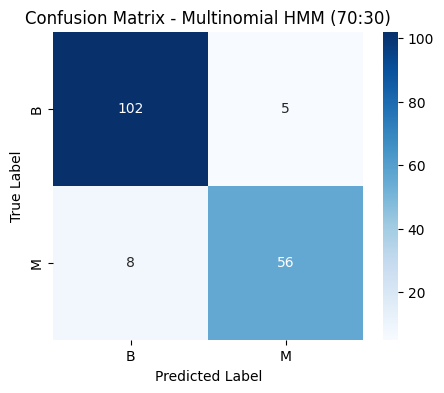

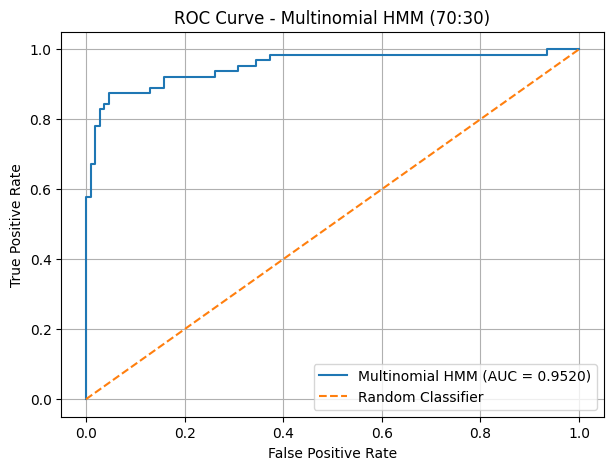


AUC: 0.9519567757009346


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

from hmmlearn import hmm


# ==========================================
# 1. Load Dataset
# ==========================================

dataset = pd.read_csv("/content/wdbc.data", header=None)

# Column 0  = ID
# Column 1  = Diagnosis
# Columns 2-31 = 30 features

X = dataset.iloc[:, 2:]
y = dataset.iloc[:, 1]


# ==========================================
# 2. Convert B/M -> 0/1
# ==========================================

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
# B = 0
# M = 1


# ==========================================
# 3. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ==========================================
# 4. Scale
# ==========================================

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================
# 5. Discretize into 0-9
# ==========================================

X_train = (X_train * 9).astype(int)
X_test = (X_test * 9).astype(int)

print("Minimum:", X_train.min())
print("Maximum:", X_train.max())


# ==========================================
# 6. Separate classes
# ==========================================

X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]


# ==========================================
# 7. Convert observations to counts
# ==========================================
# Each feature value is treated as a category 0-9.
#
# For MultinomialHMM:
# observation = count vector
#
# Example:
# value 3 -> [0,0,0,1,0,0,0,0,0,0]
#
# 10 possible categories -> 10-dimensional vector


def convert_to_counts(X):

    n_samples, n_features = X.shape

    result = np.zeros(
        (n_samples, n_features, 10),
        dtype=int
    )

    for i in range(n_samples):
        for j in range(n_features):

            category = X[i, j]

            result[i, j, category] = 1

    return result


X_train_0_counts = convert_to_counts(X_train_0)
X_train_1_counts = convert_to_counts(X_train_1)


# ==========================================
# 8. Flatten sequences
# ==========================================

X_train_0_seq = X_train_0_counts.reshape(-1, 10)
X_train_1_seq = X_train_1_counts.reshape(-1, 10)


# Each patient has 30 observations
lengths_0 = [30] * len(X_train_0)
lengths_1 = [30] * len(X_train_1)


# ==========================================
# 9. Create Multinomial HMMs
# ==========================================

model_0 = hmm.MultinomialHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)

model_1 = hmm.MultinomialHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)


# ==========================================
# 10. Train
# ==========================================

model_0.fit(
    X_train_0_seq,
    lengths=lengths_0
)

model_1.fit(
    X_train_1_seq,
    lengths=lengths_1
)


# ==========================================
# 11. Training Curves
# ==========================================

history_0 = list(model_0.monitor_.history)
history_1 = list(model_1.monitor_.history)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history_0) + 1),
    history_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(history_1) + 1),
    history_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("Training Curve - Multinomial HMM (70:30)")
plt.legend()
plt.grid()

plt.show()


# ==========================================
# 12. Loss Curves
# ==========================================

loss_0 = [-x for x in history_0]
loss_1 = [-x for x in history_1]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_0) + 1),
    loss_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(loss_1) + 1),
    loss_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Negative Log Likelihood")
plt.title("Loss Curve - Multinomial HMM (70:30)")
plt.legend()
plt.grid()

plt.show()


# ==========================================
# 13. Prediction
# ==========================================

y_pred = []
decision_scores = []


for sample in X_test:

    # Convert the 30 feature values
    # into one-hot count vectors

    sample_counts = np.zeros(
        (30, 10),
        dtype=int
    )

    for j in range(10):

        category = sample[j]

        sample_counts[j, category] = 1


    # Score using both HMMs

    score_0 = model_0.score(sample_counts)

    score_1 = model_1.score(sample_counts)


    # ROC decision score

    decision_score = score_1 - score_0

    decision_scores.append(decision_score)


    # Higher likelihood = predicted class

    if score_0 > score_1:
        y_pred.append(0)
    else:
        y_pred.append(1)


y_pred = np.array(y_pred)
decision_scores = np.array(decision_scores)


# ==========================================
# 14. Evaluation
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n==============================================")
print("SUPERVISED MULTINOMIAL HMM")
print("BREAST CANCER DATASET")
print("TRAIN : TEST = 70 : 30")
print("==============================================")

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPerformance Evaluation:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# ==========================================
# 15. Confusion Matrix Heatmap
# ==========================================

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["B", "M"],
    yticklabels=["B", "M"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Multinomial HMM (70:30)")

plt.show()


# ==========================================
# 16. ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_scores
)

auc = roc_auc_score(
    y_test,
    decision_scores
)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Multinomial HMM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multinomial HMM (70:30)")
plt.legend()
plt.grid()

plt.show()

print("\nAUC:", auc)

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Classes: ['B' 'M']
Minimum value: 0
Maximum value: 9
Data type: int64


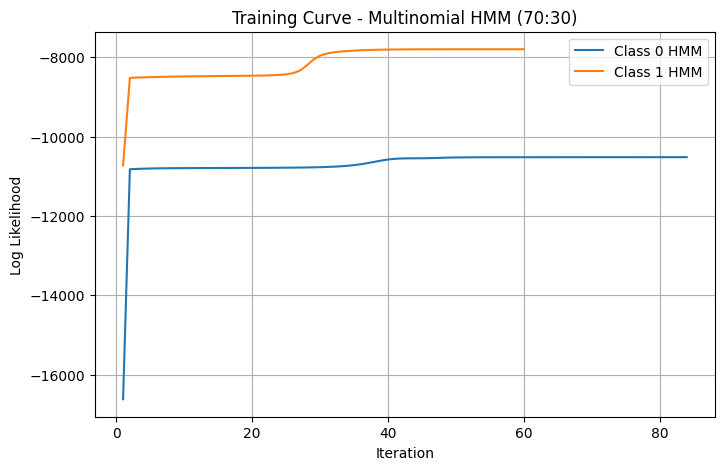

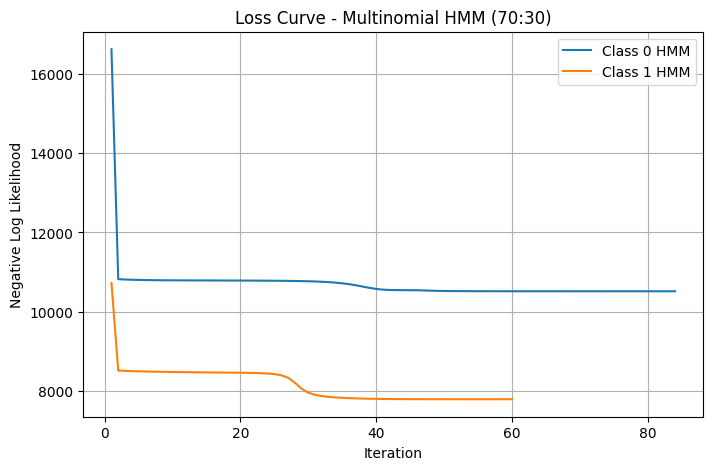


MULTINOMIAL HMM
BREAST CANCER DATASET
TRAIN : TEST = 70 : 30

Confusion Matrix:
[[103   4]
 [ 10  54]]

Accuracy:
0.9181286549707602

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       107
           1       0.93      0.84      0.89        64

    accuracy                           0.92       171
   macro avg       0.92      0.90      0.91       171
weighted avg       0.92      0.92      0.92       171



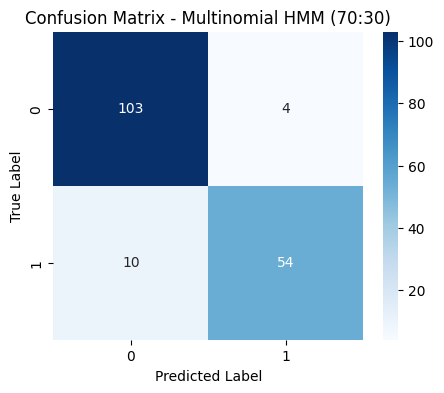

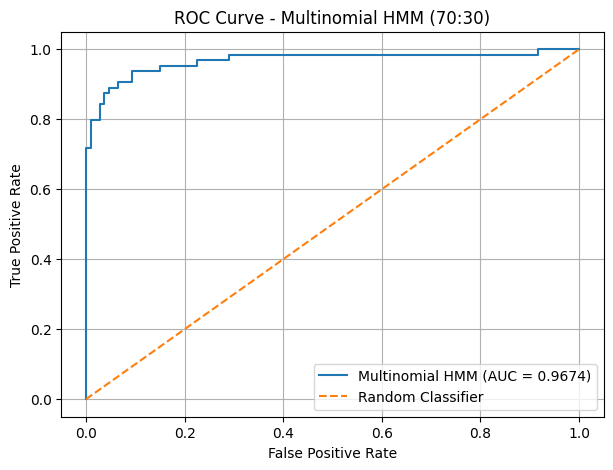


AUC: 0.9674357476635513


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Dataset Preparation
# ==========================================

dataset = pd.read_csv("/content/wdbc.data", header=None)

# Column 0 = ID
# Column 1 = Diagnosis
# Columns 2-31 = 30 features

X = dataset.iloc[:, 2:]
y = dataset.iloc[:, 1]

# Convert B/M into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)


# ==========================================
# 2. Scale the data
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

# Convert values into integers from 0 to 9
X = (X * 9).astype(int)

# Make sure values are non-negative
X[X < 0] = 0

print("Minimum value:", X.min())
print("Maximum value:", X.max())
print("Data type:", X.dtype)


# ==========================================
# 3. Train-Test Split (70:30)
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ==========================================
# 4. Separate data by class
# ==========================================

X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]


# ==========================================
# 5. Convert observations for Multinomial HMM
# ==========================================
#
# Values are 0-9.
#
# MultinomialHMM expects count vectors.
#
# Example:
# value = 3
# becomes
# [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
#
# There are 10 possible categories (0-9).


def convert_to_multinomial(X):

    n_samples, n_features = X.shape

    result = np.zeros(
        (n_samples, n_features, 10),
        dtype=int
    )

    for i in range(n_samples):
        for j in range(n_features):

            category = X[i, j]

            result[i, j, category] = 1

    return result


X_train_0 = convert_to_multinomial(X_train_0)
X_train_1 = convert_to_multinomial(X_train_1)


# ==========================================
# 6. Convert each row into a sequence
# ==========================================

X_train_0_seq = X_train_0.reshape(-1, 10)
X_train_1_seq = X_train_1.reshape(-1, 10)

# Each row contains 30 observations
lengths_0 = [30] * len(X_train_0)
lengths_1 = [30] * len(X_train_1)


# ==========================================
# 7. Create Multinomial HMM models
# ==========================================

from hmmlearn import hmm

model_0 = hmm.MultinomialHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)

model_1 = hmm.MultinomialHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)


# ==========================================
# 8. Train the HMMs
# ==========================================

model_0.fit(
    X_train_0_seq,
    lengths=lengths_0
)

model_1.fit(
    X_train_1_seq,
    lengths=lengths_1
)


# ==========================================
# 9. Training Curves
# ==========================================

history_0 = list(model_0.monitor_.history)
history_1 = list(model_1.monitor_.history)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history_0) + 1),
    history_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(history_1) + 1),
    history_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("Training Curve - Multinomial HMM (70:30)")
plt.legend()
plt.grid()

plt.show()


# ==========================================
# 10. Loss Curves
# ==========================================

loss_0 = [-x for x in history_0]
loss_1 = [-x for x in history_1]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_0) + 1),
    loss_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(loss_1) + 1),
    loss_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Negative Log Likelihood")
plt.title("Loss Curve - Multinomial HMM (70:30)")
plt.legend()
plt.grid()

plt.show()


# ==========================================
# 11. Prediction
# ==========================================

y_pred = []

# Continuous scores for ROC
decision_scores = []


for sample in X_test:

    # Convert the 30 feature values
    # into 30 multinomial observations

    sample_seq = np.zeros(
        (30, 10),
        dtype=int
    )

    for j in range(30):

        category = sample[j]

        sample_seq[j, category] = 1


    # Score under class 0 model
    score_0 = model_0.score(sample_seq)

    # Score under class 1 model
    score_1 = model_1.score(sample_seq)


    # Continuous classification score
    decision_score = score_1 - score_0

    decision_scores.append(decision_score)


    # Higher likelihood = predicted class
    if score_0 > score_1:
        y_pred.append(0)
    else:
        y_pred.append(1)


y_pred = np.array(y_pred)
decision_scores = np.array(decision_scores)


# ==========================================
# 12. Evaluation
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n==============================================")
print("MULTINOMIAL HMM")
print("BREAST CANCER DATASET")
print("TRAIN : TEST = 70 : 30")
print("==============================================")

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPerformance Evaluation:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# ==========================================
# 13. Confusion Matrix Heatmap
# ==========================================

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Multinomial HMM (70:30)")

plt.show()


# ==========================================
# 14. ROC Curve and AUC
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_scores
)

auc = roc_auc_score(
    y_test,
    decision_scores
)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Multinomial HMM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multinomial HMM (70:30)")
plt.legend()
plt.grid()

plt.show()

print("\nAUC:", auc)